In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df=pd.read_csv('customer_booking.csv', encoding='latin-1')
df.shape

(50000, 14)

In [31]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [32]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


In [34]:
df.duplicated().sum()

np.int64(719)

In [35]:
df=df.drop_duplicates()

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [38]:
df['booking_complete'].value_counts()

booking_complete
0    41890
1     7391
Name: count, dtype: int64

In [39]:
df.sample(10)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
46585,1,Internet,RoundTrip,17,6,1,Wed,HKTPVG,United States,1,0,0,5.33,0
38423,1,Internet,RoundTrip,106,5,3,Thu,HKTPER,Australia,0,1,0,5.62,0
18965,1,Internet,RoundTrip,6,18,15,Tue,MELPEN,Australia,1,0,1,8.83,0
19801,2,Internet,RoundTrip,82,29,3,Sun,MELSGN,Australia,1,0,1,8.83,0
32462,1,Internet,RoundTrip,49,4,10,Thu,HNDSIN,Singapore,0,0,0,7.57,0
2958,1,Internet,RoundTrip,46,25,12,Thu,BOMSYD,New Zealand,0,0,0,8.58,0
39448,2,Internet,RoundTrip,53,5,8,Sun,ICNSIN,South Korea,1,0,0,6.62,0
23143,1,Internet,RoundTrip,55,22,1,Tue,PERPNH,Australia,1,0,0,5.62,0
22691,1,Mobile,RoundTrip,55,60,6,Thu,PENPVG,Malaysia,1,0,0,5.33,0
37057,2,Internet,RoundTrip,79,5,18,Tue,DMKMRU,Thailand,1,1,1,7.42,0


In [40]:
df = pd.read_csv('customer_booking.csv', encoding='latin-1').drop_duplicates()
df['total_add_ons'] = (df['wants_extra_baggage'] + 
                       df['wants_preferred_seat'] + 
                       df['wants_in_flight_meals'])

NAVY, RED = '#002147', '#E01937'

def save(name):
    plt.tight_layout()
    plt.savefig(name, dpi=150, bbox_inches='tight')
    plt.show()

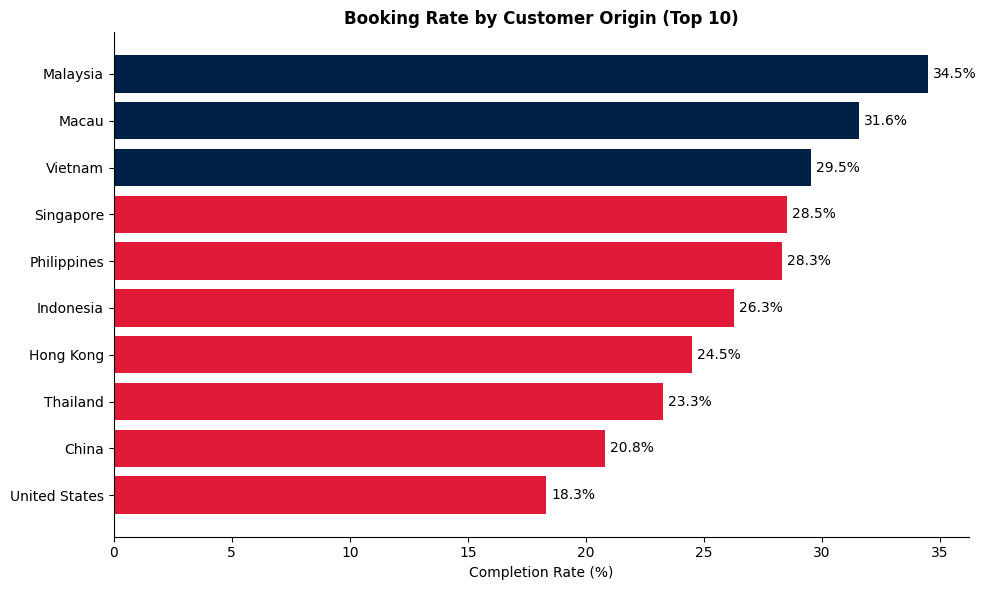

In [41]:
data = (df.groupby('booking_origin')['booking_complete']
          .agg(['mean','count']).query('count>=200')
          .sort_values('mean').tail(10))
data['mean'] *= 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(data.index, data['mean'],
        color=[NAVY if i>=7 else RED for i in range(10)])
ax.set_title('Booking Rate by Customer Origin (Top 10)', fontweight='bold')
ax.set_xlabel('Completion Rate (%)')
[ax.text(v+0.2, i, f'{v:.1f}%', va='center') 
 for i, v in enumerate(data['mean'])]
ax.spines[['top','right']].set_visible(False)
save('chart1_origin.png')

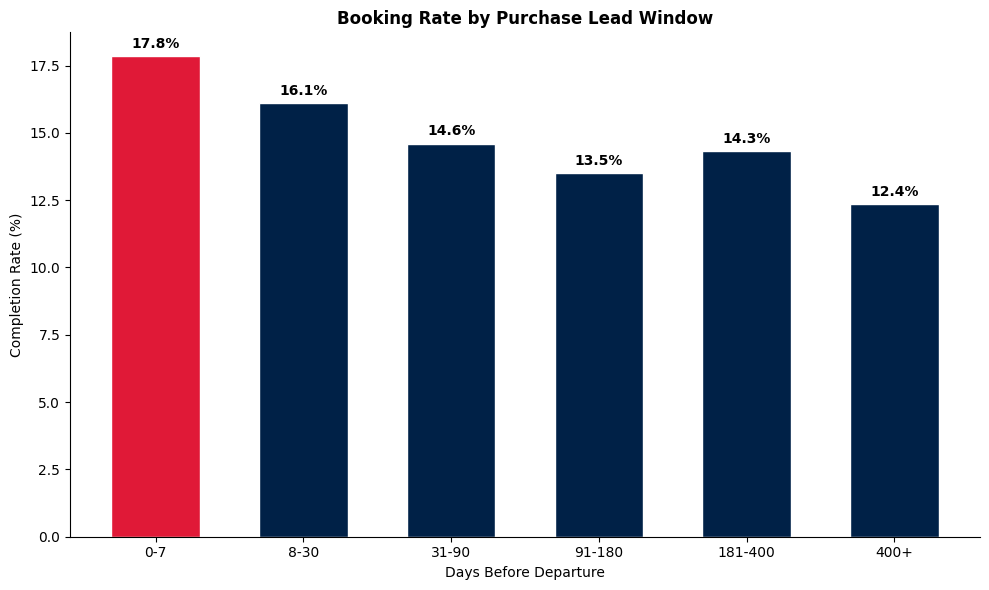

In [42]:
df['lead_group'] = pd.cut(df['purchase_lead'],
    bins=[0,7,30,90,180,400,900],
    labels=['0-7','8-30','31-90','91-180','181-400','400+'])
data = df.groupby('lead_group', observed=True)['booking_complete'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = [RED if v == data.max() else NAVY for v in data]
ax.bar(data.index, data.values, color=colors, edgecolor='white', width=0.6)
ax.set_title('Booking Rate by Purchase Lead Window', fontweight='bold')
ax.set_ylabel('Completion Rate (%)')
ax.set_xlabel('Days Before Departure')
[ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold') 
 for i, v in enumerate(data)]
ax.spines[['top','right']].set_visible(False)
save('chart2_lead.png')

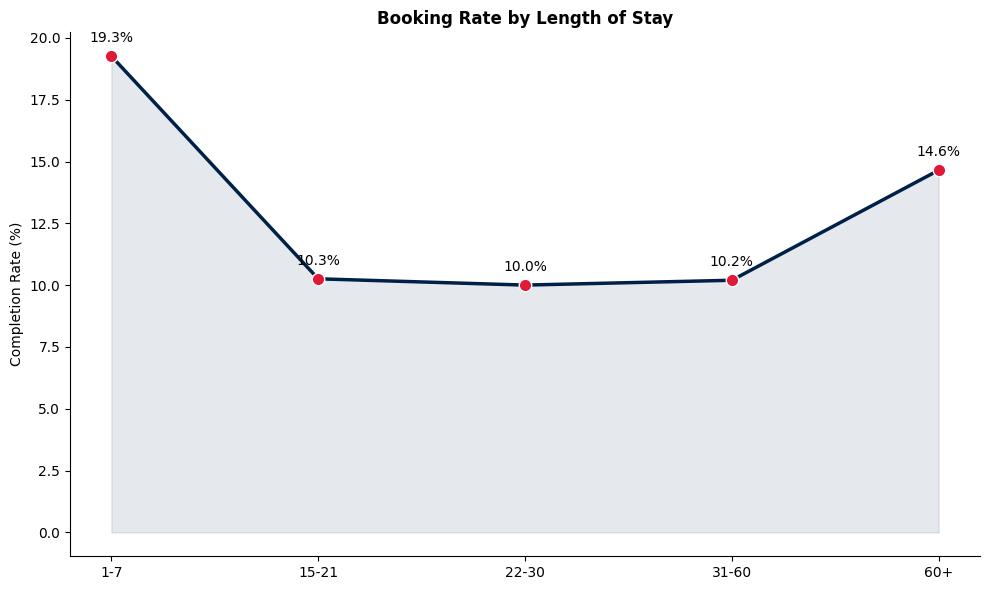

In [43]:
df['stay_group'] = pd.cut(df['length_of_stay'],
    bins=[0,7,14,21,30,60,800],
    labels=['1-7','8-14','15-21','22-30','31-60','60+'])
data = df.groupby('stay_group', observed=True)['booking_complete'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(data)), data.values, color=NAVY, lw=2.5,
        marker='o', markersize=9, markerfacecolor=RED,
        markeredgecolor='white')
ax.fill_between(range(len(data)), data.values, alpha=0.1, color=NAVY)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index)
ax.set_title('Booking Rate by Length of Stay', fontweight='bold')
ax.set_ylabel('Completion Rate (%)')
[ax.annotate(f'{v:.1f}%', (i,v), xytext=(0,10), 
  textcoords='offset points', ha='center') 
 for i, v in enumerate(data)]
ax.spines[['top','right']].set_visible(False)
save('chart3_stay.png')

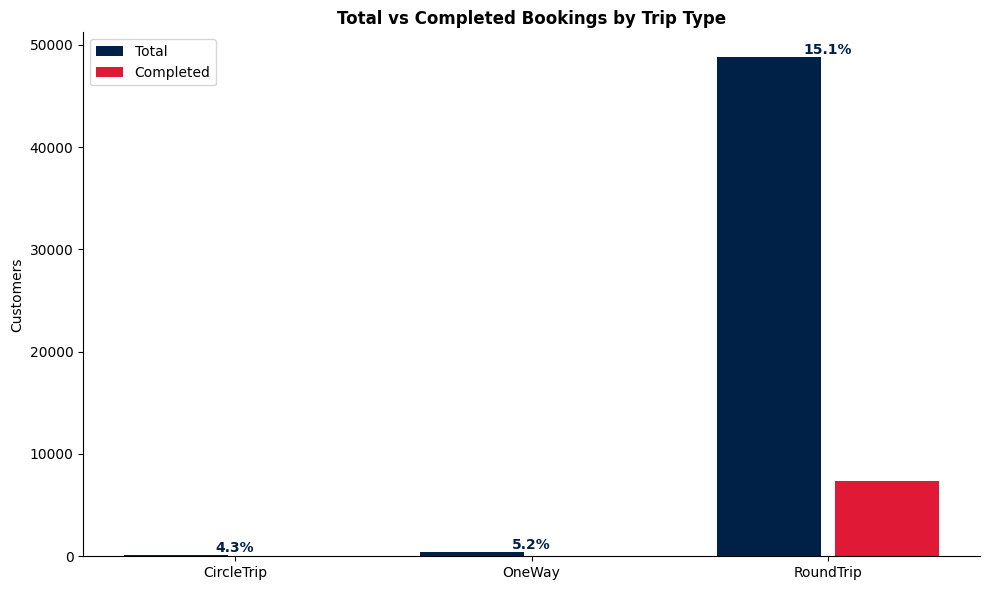

In [44]:
data = df.groupby('trip_type').agg(
    total=('booking_complete','count'),
    booked=('booking_complete','sum')).reset_index()
data['rate'] = data['booked'] / data['total'] * 100
x = np.arange(len(data))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x-0.2, data['total'],  0.35, label='Total',    color=NAVY)
ax.bar(x+0.2, data['booked'], 0.35, label='Completed', color=RED)
ax.set_xticks(x)
ax.set_xticklabels(data['trip_type'])
ax.set_title('Total vs Completed Bookings by Trip Type', fontweight='bold')
ax.set_ylabel('Customers')
ax.legend()
[ax.text(i, row['total']+300, f"{row['rate']:.1f}%", 
  ha='center', fontweight='bold', color=NAVY) 
 for i, row in data.iterrows()]
ax.spines[['top','right']].set_visible(False)
save('chart4_triptype.png')

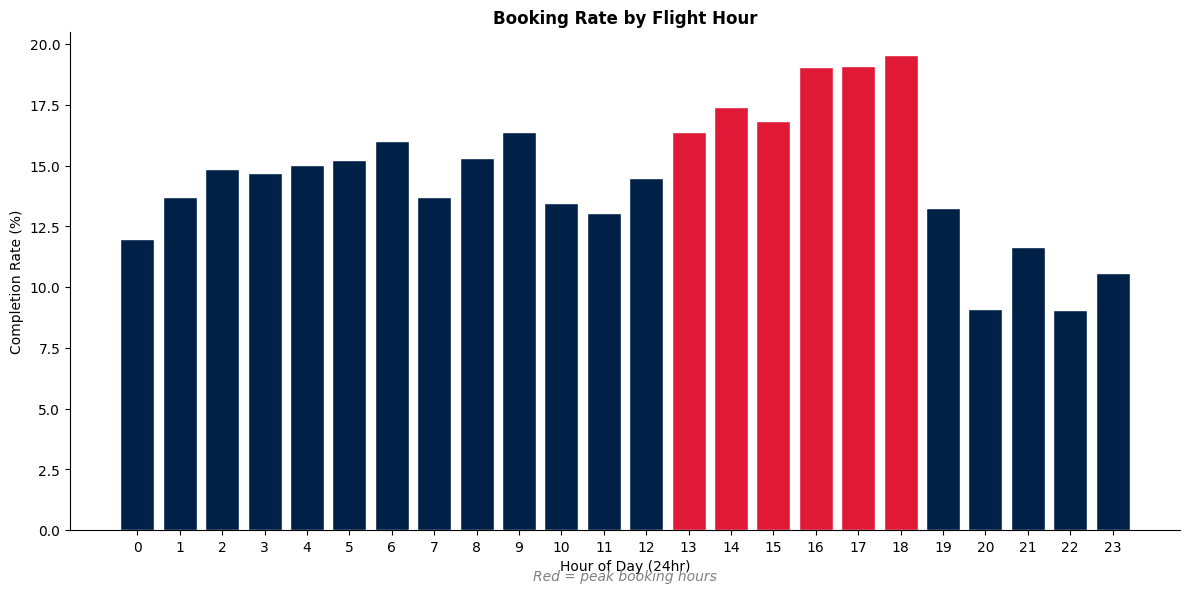

In [45]:
data = df.groupby('flight_hour')['booking_complete'].mean() * 100
colors = [RED if v >= data.quantile(0.75) else NAVY for v in data]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(data.index, data.values, color=colors, edgecolor='white')
ax.set_title('Booking Rate by Flight Hour', fontweight='bold')
ax.set_xlabel('Hour of Day (24hr)')
ax.set_ylabel('Completion Rate (%)')
ax.set_xticks(range(0, 24))
ax.text(0.5, -0.1, 'Red = peak booking hours',
        transform=ax.transAxes, ha='center', color='grey', style='italic')
ax.spines[['top','right']].set_visible(False)
save('chart5_hour.png')

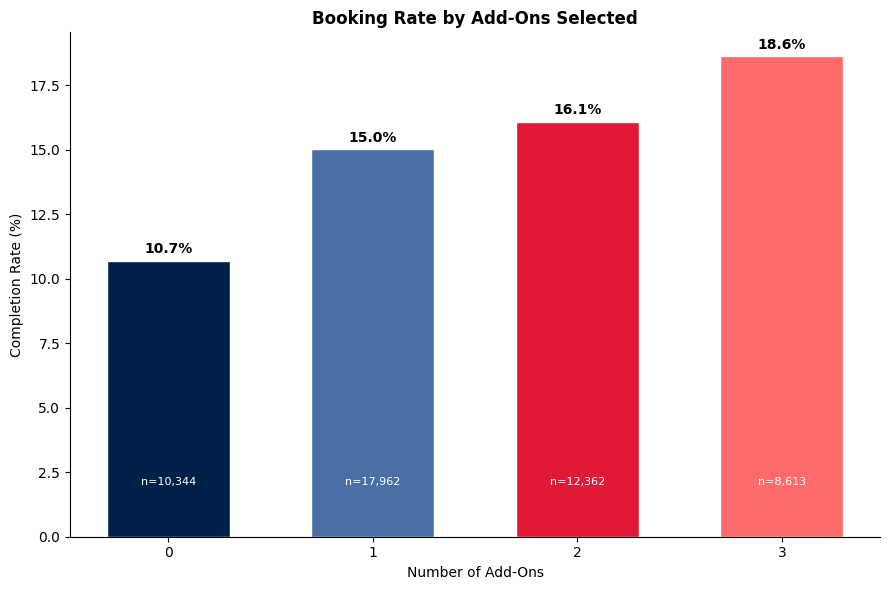

In [46]:
data  = df.groupby('total_add_ons')['booking_complete'].mean() * 100
count = df.groupby('total_add_ons').size()
colors = [NAVY, '#4A6FA5', RED, '#FF6B6B']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(data.index, data.values, 
              color=colors[:len(data)], edgecolor='white', width=0.6)
ax.set_title('Booking Rate by Add-Ons Selected', fontweight='bold')
ax.set_xlabel('Number of Add-Ons')
ax.set_ylabel('Completion Rate (%)')
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['0','1','2','3'])
[ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', 
  ha='center', fontweight='bold') for bar, v in zip(bars, data)]
[ax.text(bar.get_x()+bar.get_width()/2, 2, f'n={n:,}', 
  ha='center', color='white', fontsize=8) for bar, n in zip(bars, count)]
ax.spines[['top','right']].set_visible(False)
save('chart6_addons.png')

In [47]:
#customers who want MORE extras are more likely to complete booking
df['total_add_ons'] = (df['wants_extra_baggage'] + df['wants_preferred_seat'] + df['wants_in_flight_meals'])
print(df['total_add_ons'].value_counts().sort_index())

total_add_ons
0    10344
1    17962
2    12362
3     8613
Name: count, dtype: int64


In [48]:
df = df.drop(columns=['lead_group', 'stay_group'], errors='ignore')

In [49]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Columns that need encoding
cat_cols = ['sales_channel', 'trip_type', 
            'flight_day', 'route', 'booking_origin']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.dtypes)
print("\nSample after encoding:")
df.head()


num_passengers             int64
sales_channel              int64
trip_type                  int64
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                 int64
route                      int64
booking_origin             int64
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
total_add_ons              int64
dtype: object

Sample after encoding:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,total_add_ons
0,2,0,2,262,19,7,2,0,61,1,0,0,5.52,0,1
1,1,0,2,112,20,3,2,0,61,0,0,0,5.52,0,0
2,2,0,2,243,22,17,6,0,36,1,1,0,5.52,0,2
3,1,0,2,96,31,4,2,0,61,0,0,1,5.52,0,1
4,2,0,2,68,22,15,6,0,36,1,0,1,5.52,0,2


In [50]:
X = df.drop(columns=['booking_complete'])
y = df['booking_complete']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (49281, 14)
Target shape: (49281,)

Feature columns: ['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_day', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'total_add_ons']


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y      
)

print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])


model = RandomForestClassifier(
    n_estimators=100,        
    max_depth=10,            
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1                
)

model.fit(X_train, y_train)
print("\nModel trained successfully")

Training rows: 39424
Testing rows:  9857

Model trained successfully


In [52]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score)
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Basic predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=['Not Booked', 'Booked']))
roc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc:.4f}")


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    fold_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    fold_model.fit(X_tr, y_tr)
    y_prob = fold_model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, y_prob)
    cv_scores.append(score)
    print(f"Fold {fold+1}: ROC-AUC = {score:.4f}")

print(f"\nMean ROC-AUC : {np.mean(cv_scores):.4f}")
print(f"Std deviation: {np.std(cv_scores):.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not Booked       0.93      0.72      0.81      8379
      Booked       0.30      0.69      0.42      1478

    accuracy                           0.71      9857
   macro avg       0.62      0.70      0.61      9857
weighted avg       0.83      0.71      0.75      9857

ROC-AUC Score: 0.7628
Fold 1: ROC-AUC = 0.7608
Fold 2: ROC-AUC = 0.7631
Fold 3: ROC-AUC = 0.7637
Fold 4: ROC-AUC = 0.7621
Fold 5: ROC-AUC = 0.7585

Mean ROC-AUC : 0.7616
Std deviation: 0.0018


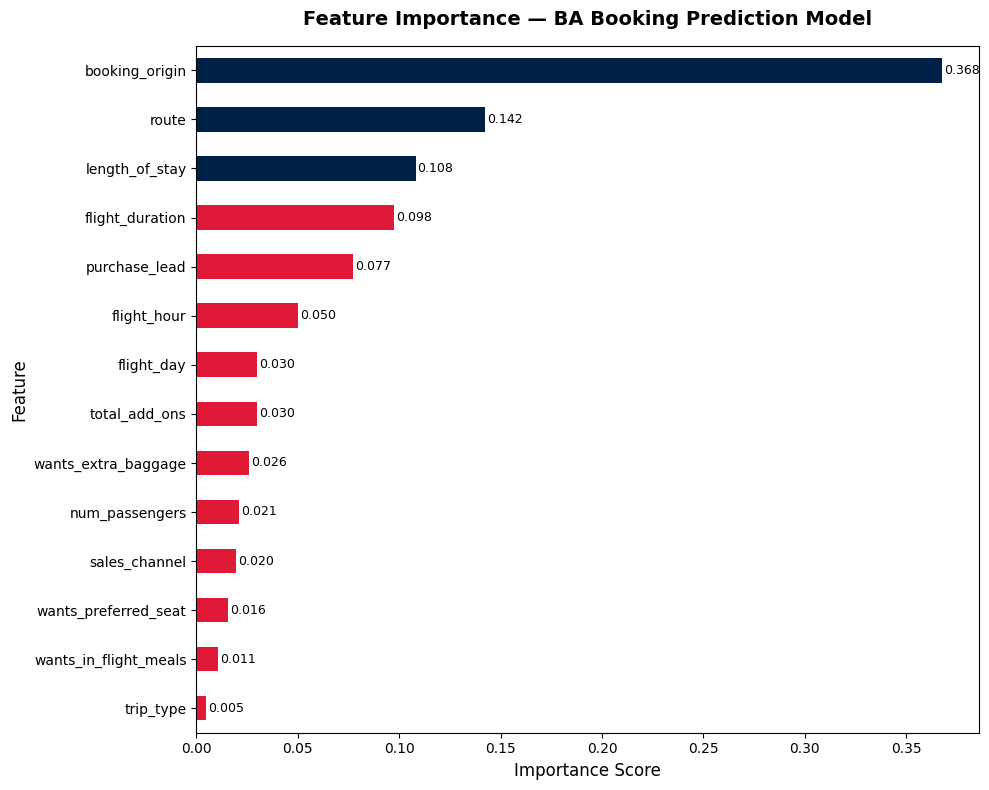

Chart saved as feature_importance.png


In [53]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colours = ['#002147' if i >= len(importances)-3 
           else '#E01937' for i in range(len(importances))]

importances.plot(
    kind='barh', 
    ax=ax,
    color=colours
)

ax.set_title('Feature Importance — BA Booking Prediction Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

# Add value labels
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as feature_importance.png")